In [1]:
import numpy as np 
from uncertainties import ufloat
from uncertainties import unumpy as unp
from IPython.display import Latex, HTML, Math, display
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
import pandas as pd
from scipy import constants as c
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator
from sklearn.metrics import r2_score
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset, zoomed_inset_axes



# zum import von py Dateien
from pathlib import Path
import sys

# Projekt-Root zum importieren von Helper
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from Helper import Helper 

27.4+/-1.1


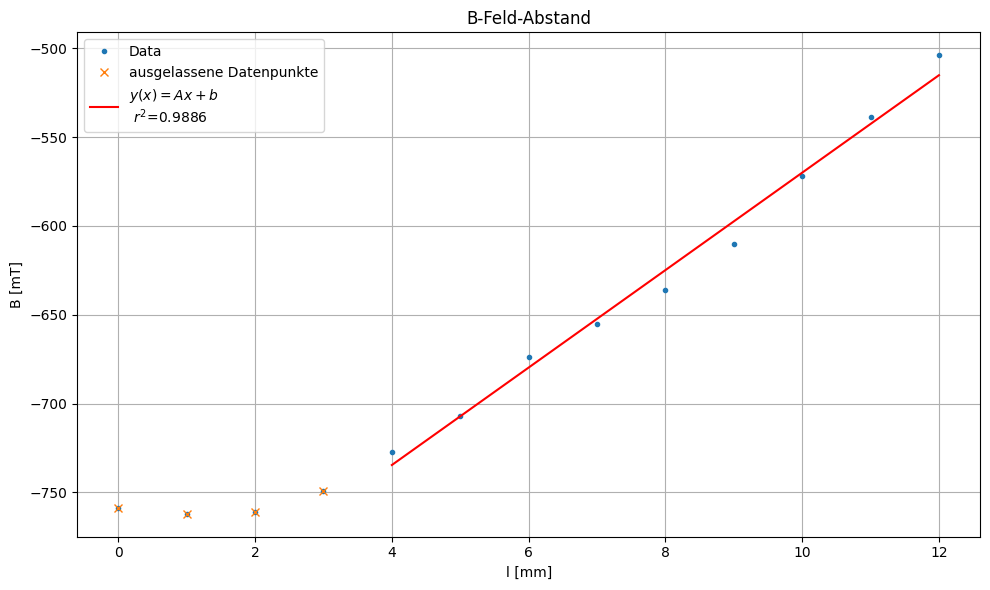

-0.00040+/-0.00006


In [91]:
# fits

B = -1*np.array((775,778,777,765,743,723,690,671,652,626,588,555,520))+16 # mT +-4

l = np.array((0,1,2,3,4,5,6,7,8,9,10,11,12)) #mm +-0.5


# linfit

popt_1, pcov_1 = curve_fit(Helper.linfit, l[4:], B[4:], p0=[1, 1])

a_opt, b_opt = popt_1
x_model_1 = np.linspace(min(l[4:]), max(l[4:]), 100)
y_model_1 = Helper.linfit(x_model_1, a_opt, b_opt)
perr_1 = np.sqrt(np.diag(pcov_1))

A_1 = ufloat(a_opt,perr_1[0])

print(A_1)
r2_1 = Helper.r2_curve_fit(popt_1, l[4:], B[4:], Helper.linfit)






# plot
plt.figure(figsize=(10, 6))
plt.plot(l, B,".", label="Data")
plt.plot(l[:4], B[:4],"x", label="ausgelassene Datenpunkte")
plt.plot(x_model_1, y_model_1, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2_1:.4f}")
# plt.errorbar(H_4, Pro, fmt='o', yerr= Pro_uu, capsize=3, markersize=4, label="errorbars")
# plt.plot(V, p, "o")
# plt.xscale('function', functions=(forward, inverse))
plt.ylabel(r"B [mT]")
plt.xlabel(r"l [mm]")
plt.legend()
plt.title("B-Feld-Abstand")
plt.tight_layout()
plt.grid()
plt.show()

V = ufloat(0.135,0.02)*10**(-6)
F = ufloat(-0.70,0.03)

chi = (F*4*c.pi*10**(-7))/(V*600*A_1)
print(chi)

(2.92+/-0.10)e-05
0.00419+/-0.00008


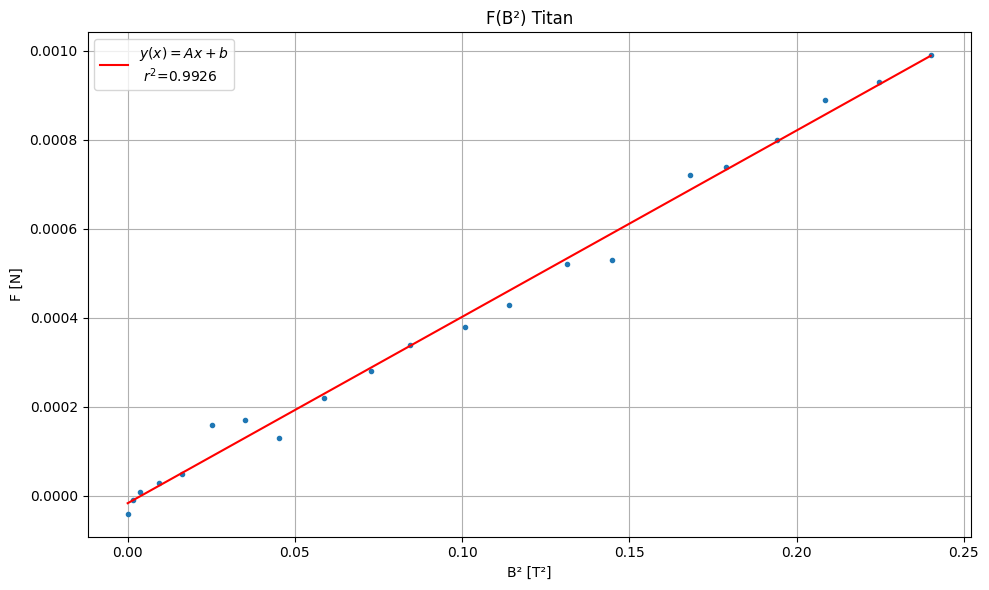

0.000360+/-0.000014


In [89]:
# Titan

d = ufloat(0.61,0.01) #cm

A = c.pi*(d/2)**2*10**(-4)
print(A)

Data = pd.read_csv("Titan.csv", sep=',', decimal='.')   # read csv für den Graphen


B = Data["B"].to_numpy()/1000    # T MF Data

F = Data["F"].to_numpy()/1000    # N Kraft Data


# #linfit

popt_1, pcov_1 = curve_fit(Helper.linfit, B**2, F, p0=[1, 1])

a_opt, b_opt = popt_1
x_model_1 = np.linspace(min(B**2), max(B**2), 100)
y_model_1 = Helper.linfit(x_model_1, a_opt, b_opt)
perr_1 = np.sqrt(np.diag(pcov_1))

A_1 = ufloat(a_opt,perr_1[0])

print(A_1)
r2_1 = Helper.r2_curve_fit(popt_1, B**2, F, Helper.linfit)






# plot
plt.figure(figsize=(10, 6))
plt.plot(B**2, F,".")
plt.plot(x_model_1, y_model_1, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2_1:.4f}")
# plt.errorbar(H_4, Pro, fmt='o', yerr= Pro_uu, capsize=3, markersize=4, label="errorbars")
# plt.plot(V, p, "o")
# plt.xscale('function', functions=(forward, inverse))
plt.ylabel(r"F [N]")
plt.xlabel(r"B² [T²]")
plt.legend()
plt.title("F(B²) Titan")
plt.tight_layout()
plt.grid()
plt.show()



chi_1 = (A_1*2*4*c.pi*10**(-7))/A
print(chi_1)


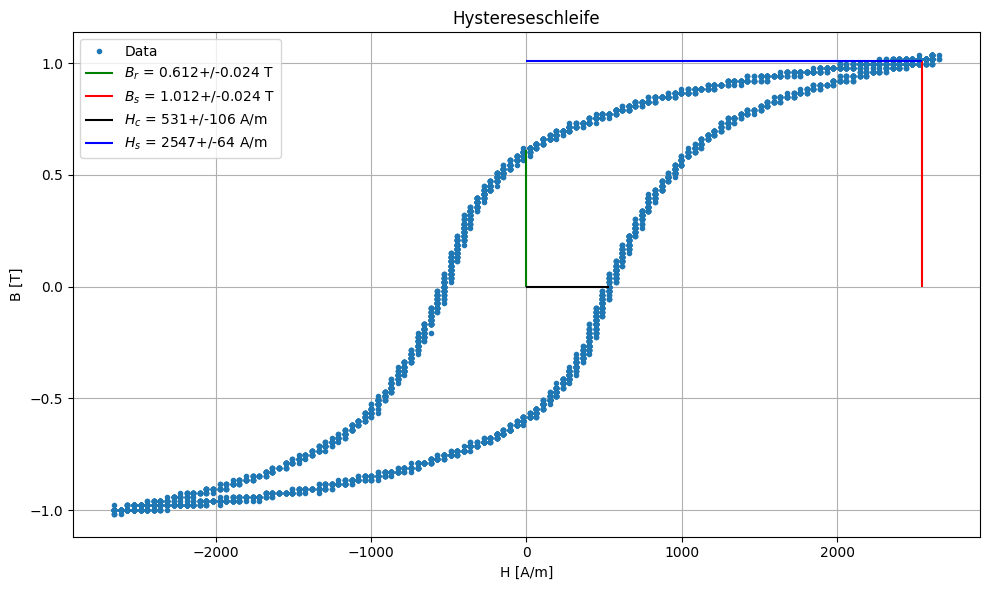

4.7081218274111665 212.2844827586207


In [96]:
# blabla

R = 70700 # Ohm
C = 10.6*10**(-6) # F
n_2 = 788
A = 2.02/10000 # m²
n_1 = 197
L = 0.02 # m
R_v = 46.4 # Ohm

v_B = (R*C)/(n_2*A)


v_H = (n_1)/(L*R_v)

I = ufloat(150.4,0.3) # mA

B_r = ufloat(130,5)/1000*v_B # mV
H_c = ufloat(2.5,0.5)*v_H # V
H_s = ufloat(12, 0.3)*v_H # V
B_s = ufloat(215,5)/1000*v_B # mV







Data = pd.read_csv("hkurve.csv", sep=',', decimal='.')   # read csv für den Graphen


U_1 = Data["CH1"].to_numpy()    # T MF Data

U_2 = Data["CH2"].to_numpy()    # N Kraft Data


B = (R*C)/(n_2*A)*U_2

H = (n_1*U_1)/(L*R_v)

# plot
plt.figure(figsize=(10, 6))
plt.plot(H, B,".", label="Data")
# plt.plot(x_model_1, y_model_1, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2_1:.4f}")
# plt.errorbar(H_4, Pro, fmt='o', yerr= Pro_uu, capsize=3, markersize=4, label="errorbars")
# plt.plot(V, p, "o")
# plt.xscale('function', functions=(forward, inverse))
plt.vlines(0, 0, unp.nominal_values(B_r), linestyles="-", colors="g", label=f"$B_r$ = {B_r:.3f} T")
plt.vlines(unp.nominal_values(H_s), 0, unp.nominal_values(B_s), linestyles="-", colors="r", label=f"$B_s$ = {B_s:.3f} T")

plt.hlines(0,0, unp.nominal_values(H_c), colors="black", label=f"$H_c$ = {H_c:.0f} A/m")
plt.hlines(unp.nominal_values(B_s),0,unp.nominal_values(H_s), colors="b", label=f"$H_s$ = {H_s:.-1f} A/m")
plt.ylabel(r"B [T]")
plt.xlabel(r"H [A/m]")
plt.legend()
plt.title("Hystereseschleife")
plt.tight_layout()
plt.grid()
plt.show()


v_B = (R*C)/(n_2*A)


v_H = (n_1)/(L*R_v)

print(v_B,v_H)